# 02 – Baseline Modeller

**Proje:** EUR/USD 1H Forex Zaman Serisi Tahmini  
**Ders:** Yapay Zekaya Giriş – Dönem Projesi (Hafta 4 Teslimi)  
**Öğrenci:** Bilal – `b200101025`

## Amaç

EDA'da gördük: log-getiri durağan, yaklaşık sıfır ortalamalı, ağır kuyruklu ve belirgin **volatilite kümelenmesi** içeriyor. Yani EUR/USD 1H bir rastgele yürüyüşe çok yakındır. Bu nedenle karışık modellere geçmeden önce **kolay kırılamayan taban** çizgileri koyuyoruz:

1. **Naive-Last-Value**: bir sonraki kapanışta değişim yok (log_ret=0)
2. **Drift**: eğitim ortalama log-getirisi kadar sabit eğim
3. **Seasonal Naive 24H**: "dün aynı saatte ne olduysa bugün de aynen olur"
4. **Seasonal Naive 168H**: hafta döngüsünü hedefler
5. **Moving Average (24H)**: son 24 saatin ortalama log-getirisi
6. **AR(p)**: log-getirinin klasik lineer oto-regresif fit'i (p AIC ile seçilecek)

Tüm modeller **1-adım-önce (one-step-ahead)** tahmin yaparak validation ve test setinde **rolling** olarak değerlendirilir. Metrikler:

- **RMSE / MAE** (hem log-getiri baz puan hem close pip cinsinden)
- **MAPE** close üzerinde
- **Yön Doğruluğu (%)** — yukarı/aşağı yönünü kaç gozlemde doğru bildi

Sonuçlar `data/processed/baseline_scores.csv` olarak kaydediliyor; DL ve ML defterleri bu referansla karşılaştırılacak.

## 0. Ortam

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_eurusd, train_val_test_split
from src.metrics import score_all

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['figure.dpi'] = 100

RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'eurusd_h1.csv'
FIG_DIR = PROJECT_ROOT / 'docs' / 'images'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print('Python:', sys.version.split()[0])

Python: 3.13.13


## 1. Veri ve Split

Train / val / test sınırları `src/data_loader.py`'de sabitlenmiştir (sızdırma olmaması için tek yerden yönetiliyor). Tahmin hedefimiz **log-getiri**, görselleştirme için onu close'a geri çeviriyoruz:

\[
\hat{P}_{t+1} = P_t \cdot \exp(\hat{r}_{t+1})
\]

In [2]:
df = load_raw_eurusd(RAW_CSV)
df['log_ret'] = np.log(df['close']).diff()
df = df.dropna(subset=['log_ret'])

train, val, test = train_val_test_split(df)
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:>5}: {len(part):>7,} satır   |  {part.index.min()}  →  {part.index.max()}')

train:  81,923 satır   |  2009-10-16 01:00:00  →  2022-12-30 23:00:00
  val:   6,206 satır   |  2023-01-02 08:00:00  →  2023-12-29 23:00:00
 test:  12,477 satır   |  2024-01-02 01:00:00  →  2026-01-06 07:00:00


## 2. Tahmin Çerçevesi

Her model bir `predict_rolling(series, ...)` fonksiyonu üretir: girdi, train+degerlendirilecek seg olacak şekilde "geçmişi kumalative" kullanır. Sonuç, tahmin edilen **log-getiri** dizisidir. Bu diziden close tahmini türetilir ve gercek ile kiyaslanır.

In [3]:
def reconstruct_close(last_close_before: float, log_ret_pred: np.ndarray, close_true: pd.Series) -> np.ndarray:
    """1-adım önce rolling: her adımda gerçek önceki close üzerine log_ret_pred uygulanır.

    Bu, forward-testin zaman çizelgesini taklit eder (modele gerçek geçmiş akar, tahmin sadece bir adımlıktır).
    """
    prev = np.concatenate([[last_close_before], close_true.values[:-1]])
    return prev * np.exp(log_ret_pred)


def evaluate(name: str, target_segment: pd.DataFrame, train_segment: pd.DataFrame, log_ret_pred: np.ndarray) -> dict:
    y_true_ret = target_segment['log_ret'].values
    y_true_close = target_segment['close'].values
    last_close_before = float(train_segment['close'].iloc[-1])
    y_pred_close = reconstruct_close(last_close_before, log_ret_pred, target_segment['close'])
    sc = score_all(y_true_ret, log_ret_pred, y_true_close, y_pred_close)
    sc['model'] = name
    return sc

## 3. Baseline 1 — Naive Last Value

Tahmin: `log_ret_{t+1} = 0`  →  `close_{t+1} = close_t`. Literatürde "rïandom walk" ön kabulünün birebir karşılığı.

In [4]:
def naive_predict(segment: pd.DataFrame) -> np.ndarray:
    return np.zeros(len(segment), dtype=np.float64)

naive_val = evaluate('naive_last_value', val, train, naive_predict(val))
naive_test = evaluate('naive_last_value', test, pd.concat([train, val]), naive_predict(test))
print('VAL :', {k: round(v, 4) if isinstance(v, float) else v for k, v in naive_val.items()})
print('TEST:', {k: round(v, 4) if isinstance(v, float) else v for k, v in naive_test.items()})

VAL : {'rmse_ret_bp': 9.616, 'mae_ret_bp': 6.3228, 'rmse_close_pip': 10.3917, 'mae_close_pip': 6.8352, 'mape_close': 0.0632, 'dir_acc_pct': 0.0, 'model': 'naive_last_value'}
TEST: {'rmse_ret_bp': 9.1256, 'mae_ret_bp': 5.791, 'rmse_close_pip': 10.0628, 'mae_close_pip': 6.4014, 'mape_close': 0.0579, 'dir_acc_pct': 0.0, 'model': 'naive_last_value'}


## 4. Baseline 2 — Drift

Eğitim setindeki ortalama log-getiri `mu` hesaplanır; her adımda aynı `mu` tahmin edilir. Beklenen: naive ile neredeyse aynı performans, çünkü `mu` 0'a çok yakın.

In [5]:
mu_train = float(train['log_ret'].mean())
mu_train_val = float(pd.concat([train, val])['log_ret'].mean())
print(f'train mu      : {mu_train:.3e}  (yaklaşık {mu_train*1e4:.2f} baz puan / saat)')
print(f'train+val mu  : {mu_train_val:.3e}')

drift_val = evaluate('drift', val, train, np.full(len(val), mu_train))
drift_test = evaluate('drift', test, pd.concat([train, val]), np.full(len(test), mu_train_val))
print('VAL :', {k: round(v, 4) for k, v in drift_val.items() if isinstance(v, float)})
print('TEST:', {k: round(v, 4) for k, v in drift_test.items() if isinstance(v, float)})

train mu      : -4.077e-06  (yaklaşık -0.04 baz puan / saat)
train+val mu  : -3.435e-06
VAL : {'rmse_ret_bp': 9.6163, 'mae_ret_bp': 6.3232, 'rmse_close_pip': 10.392, 'mae_close_pip': 6.8356, 'mape_close': 0.0632, 'dir_acc_pct': 49.8135}
TEST: {'rmse_ret_bp': 9.1258, 'mae_ret_bp': 5.7915, 'rmse_close_pip': 10.0631, 'mae_close_pip': 6.4019, 'mape_close': 0.0579, 'dir_acc_pct': 49.6567}


## 5. Baseline 3 & 4 — Seasonal Naive (24H ve 168H)

EDA'da saat × gün heatmap üzerinde bariz bir Londra/NY açılış örüntüsü görüldü. Sorusu: bu periyodik iz, naive'i yenmek için yeterli mi?

- **Seasonal-24H**: `ŷ_{t+1} = y_{t+1-24}`
- **Seasonal-168H**: `ŷ_{t+1} = y_{t+1-168}` (bir hafta önce aynı saat aynı gün)

In [6]:
def seasonal_predict(train_seg: pd.DataFrame, target_seg: pd.DataFrame, lag: int) -> np.ndarray:
    full = pd.concat([train_seg['log_ret'], target_seg['log_ret']])
    shifted = full.shift(lag).loc[target_seg.index]
    return shifted.fillna(0).values

snaive24_val = evaluate('seasonal_naive_24h', val, train, seasonal_predict(train, val, 24))
snaive24_test = evaluate('seasonal_naive_24h', test, pd.concat([train, val]), seasonal_predict(pd.concat([train, val]), test, 24))
snaive168_val = evaluate('seasonal_naive_168h', val, train, seasonal_predict(train, val, 168))
snaive168_test = evaluate('seasonal_naive_168h', test, pd.concat([train, val]), seasonal_predict(pd.concat([train, val]), test, 168))

for label, d in [('S24 val', snaive24_val), ('S24 test', snaive24_test), ('S168 val', snaive168_val), ('S168 test', snaive168_test)]:
    print(f'{label:>10}: rmse_ret_bp={d["rmse_ret_bp"]:.2f}  dir_acc%={d["dir_acc_pct"]:.2f}  pip_rmse={d["rmse_close_pip"]:.2f}')

   S24 val: rmse_ret_bp=13.67  dir_acc%=49.94  pip_rmse=14.77
  S24 test: rmse_ret_bp=12.85  dir_acc%=50.52  pip_rmse=14.17
  S168 val: rmse_ret_bp=13.49  dir_acc%=50.59  pip_rmse=14.59
 S168 test: rmse_ret_bp=12.81  dir_acc%=49.73  pip_rmse=14.14


## 6. Baseline 5 — Moving Average (24H)

Tahmin: son 24 saatin ortalama log-getirisi. Gerçek zamanlı rolling, sadece geçmiş pencereyi kullanır (forward leakage yok).

In [7]:
def ma_predict(train_seg: pd.DataFrame, target_seg: pd.DataFrame, window: int = 24) -> np.ndarray:
    full = pd.concat([train_seg['log_ret'], target_seg['log_ret']])
    ma = full.rolling(window).mean().shift(1).loc[target_seg.index]
    return ma.fillna(0).values

ma_val = evaluate('ma_24h', val, train, ma_predict(train, val, 24))
ma_test = evaluate('ma_24h', test, pd.concat([train, val]), ma_predict(pd.concat([train, val]), test, 24))
print('VAL :', {k: round(v, 4) for k, v in ma_val.items() if isinstance(v, float)})
print('TEST:', {k: round(v, 4) for k, v in ma_test.items() if isinstance(v, float)})

VAL : {'rmse_ret_bp': 9.8155, 'mae_ret_bp': 6.582, 'rmse_close_pip': 10.6073, 'mae_close_pip': 7.1155, 'mape_close': 0.0658, 'dir_acc_pct': 50.0243}
TEST: {'rmse_ret_bp': 9.3021, 'mae_ret_bp': 6.0095, 'rmse_close_pip': 10.258, 'mae_close_pip': 6.6425, 'mape_close': 0.0601, 'dir_acc_pct': 49.9152}


## 7. Baseline 6 — AR(p) Lineer Oto-Regresyon

statsmodels `AutoReg` ile log-getiride lineer AR modeli. `maxlag` AIC ile seçilir; sonra val ve test için 1-adım-önce rolling tahmin üretilir. ARIMA(p,0,0) ile denk ancak AutoReg daha hızlı.

Not: gercek bir rolling-refit ARIMA çok pahalıdır (100K+ adım). Buradaki baseline; modeli train üzerinde bir kere fit edip, sonraki saatlerde **gerçek geçmiş** lag'leri besleyen pencere tahmini yapar. DL modellerinde de aynı protokole sadık kalınacağı için karşılaştırma adil olur.

In [8]:
CANDIDATE_LAGS = [1, 2, 3, 6, 12, 24]
aics = {}
for p in CANDIDATE_LAGS:
    m = AutoReg(train['log_ret'].values, lags=p, old_names=False).fit()
    aics[p] = m.aic
best_p = min(aics, key=aics.get)
print('AIC by lag :', {k: round(v, 1) for k, v in aics.items()})
print(f'\nSeçilen p = {best_p}')

ar_model = AutoReg(train['log_ret'].values, lags=best_p, old_names=False).fit()
print(ar_model.summary().tables[1])

AIC by lag :

 {1: np.float64(-879631.2), 2: np.float64(-879617.9), 3: np.float64(-879607.9), 6: np.float64(-879569.4), 12: np.float64(-879507.5), 24: np.float64(-879365.5)}

Seçilen p = 1


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.111e-06   3.94e-06     -1.043      0.297   -1.18e-05    3.61e-06
y.L1          -0.0057      0.003     -1.631      0.103      -0.013       0.001

In [9]:
def ar_rolling_predict(ar_params: np.ndarray, lag: int, history: np.ndarray, n_steps: int, full_future: np.ndarray) -> np.ndarray:
    const, coefs = ar_params[0], ar_params[1:]
    preds = np.zeros(n_steps)
    recent = list(history[-lag:])
    for t in range(n_steps):
        yhat = const + sum(coefs[i] * recent[-1 - i] for i in range(lag))
        preds[t] = yhat
        recent.append(full_future[t])
        if len(recent) > lag:
            recent.pop(0)
    return preds

params = ar_model.params
ar_val_pred = ar_rolling_predict(params, best_p, train['log_ret'].values, len(val), val['log_ret'].values)

ar_model_tv = AutoReg(pd.concat([train, val])['log_ret'].values, lags=best_p, old_names=False).fit()
ar_test_pred = ar_rolling_predict(
    ar_model_tv.params, best_p,
    pd.concat([train, val])['log_ret'].values, len(test), test['log_ret'].values,
)

ar_val = evaluate(f'ar({best_p})', val, train, ar_val_pred)
ar_test = evaluate(f'ar({best_p})', test, pd.concat([train, val]), ar_test_pred)
print('VAL :', {k: round(v, 4) for k, v in ar_val.items() if isinstance(v, float)})
print('TEST:', {k: round(v, 4) for k, v in ar_test.items() if isinstance(v, float)})

VAL : {'rmse_ret_bp': 9.6167, 'mae_ret_bp': 6.3225, 'rmse_close_pip': 10.3925, 'mae_close_pip': 6.8349, 'mape_close': 0.0632, 'dir_acc_pct': 50.365}
TEST: {'rmse_ret_bp': 9.1247, 'mae_ret_bp': 5.7905, 'rmse_close_pip': 10.0618, 'mae_close_pip': 6.4009, 'mape_close': 0.0579, 'dir_acc_pct': 49.9394}


## 8. Karşılaştırma Tablosu

Tüm baseline'ların validation ve test skorlarını tek tabloda görmek; **hangi metriğe ilişkin sıralama** yapılıyor, hangi modelin yenilmesi gerektiğine dair çıplak gerçek bu tablo.

In [10]:
rows = []
for split_name, group in [('val', [naive_val, drift_val, snaive24_val, snaive168_val, ma_val, ar_val]),
                          ('test', [naive_test, drift_test, snaive24_test, snaive168_test, ma_test, ar_test])]:
    for r in group:
        rows.append({'split': split_name, **r})
scores = pd.DataFrame(rows)[['split', 'model', 'rmse_ret_bp', 'mae_ret_bp', 'rmse_close_pip', 'mae_close_pip', 'mape_close', 'dir_acc_pct']]
scores_display = scores.round(3).set_index(['split', 'model']).sort_index()
scores.to_csv(PROC_DIR / 'baseline_scores.csv', index=False)
print('Kaydedildi:', PROC_DIR / 'baseline_scores.csv')
scores_display

Kaydedildi: C:\Users\Gaming\Desktop\MAC\yapay zeka ödev\data\processed\baseline_scores.csv


rmse_ret_bp  mae_ret_bp  rmse_close_pip  \
split model                                                          
test  ar(1)                      9.125       5.791          10.062   
      drift                      9.126       5.791          10.063   
      ma_24h                     9.302       6.009          10.258   
      naive_last_value           9.126       5.791          10.063   
      seasonal_naive_168h       12.807       8.513          14.137   
      seasonal_naive_24h        12.845       8.423          14.173   
val   ar(1)                      9.617       6.323          10.392   
      drift                      9.616       6.323          10.392   
      ma_24h                     9.816       6.582          10.607   
      naive_last_value           9.616       6.323          10.392   
      seasonal_naive_168h       13.492       9.100          14.590   
      seasonal_naive_24h        13.675       9.139          14.772   

                           mae_close_pip  mape_close  dir_acc_pct  
split model                                                        
test  ar(1)                        6.401       0.058       49.939  
      drift                        6.402       0.058       49.657  
      ma_24h                       6.642       0.060       49.915  
      naive_last_value             6.401       0.058        0.000  
      seasonal_naive_168h          9.411       0.085       49.729  
      seasonal_naive_24h           9.310       0.084       50.521  
val   ar(1)                        6.835       0.063       50.365  
      drift                        6.836       0.063       49.813  
      ma_24h                       7.115       0.066       50.024  
      naive_last_value             6.835       0.063        0.000  
      seasonal_naive_168h          9.839       0.091       50.592  
      seasonal_naive_24h           9.877       0.091       49.943

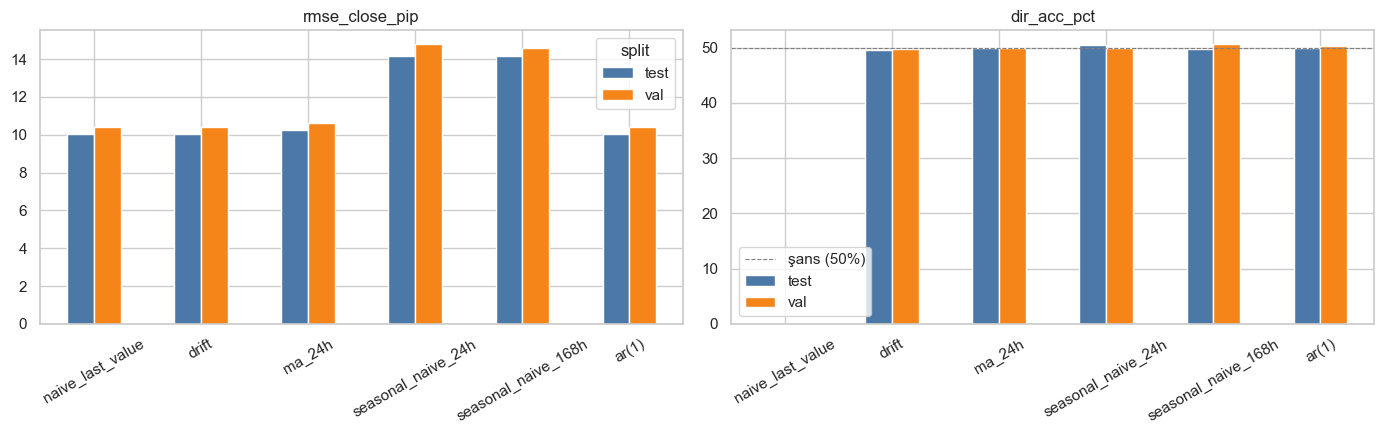

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, metric in zip(axes, ['rmse_close_pip', 'dir_acc_pct']):
    piv = scores.pivot(index='model', columns='split', values=metric)
    piv = piv.loc[['naive_last_value', 'drift', 'ma_24h', 'seasonal_naive_24h', 'seasonal_naive_168h', f'ar({best_p})']]
    piv.plot(kind='bar', ax=ax, rot=30, color=['#4c78a8', '#f58518'])
    ax.set_title(metric)
    ax.set_xlabel('')
axes[1].axhline(50, color='gray', ls='--', lw=0.8, label='şans (50%)')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'baselines_scores.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Tahmin vs Gerçek (Test Üzerinde)

Sadece test setinin ilk ~500 saatlik penceresini çiziyoruz; tüm seri çizimi okunmaz olur. Gizli mesaj: naive tahmini birebir bir adım gerideki close'tur.

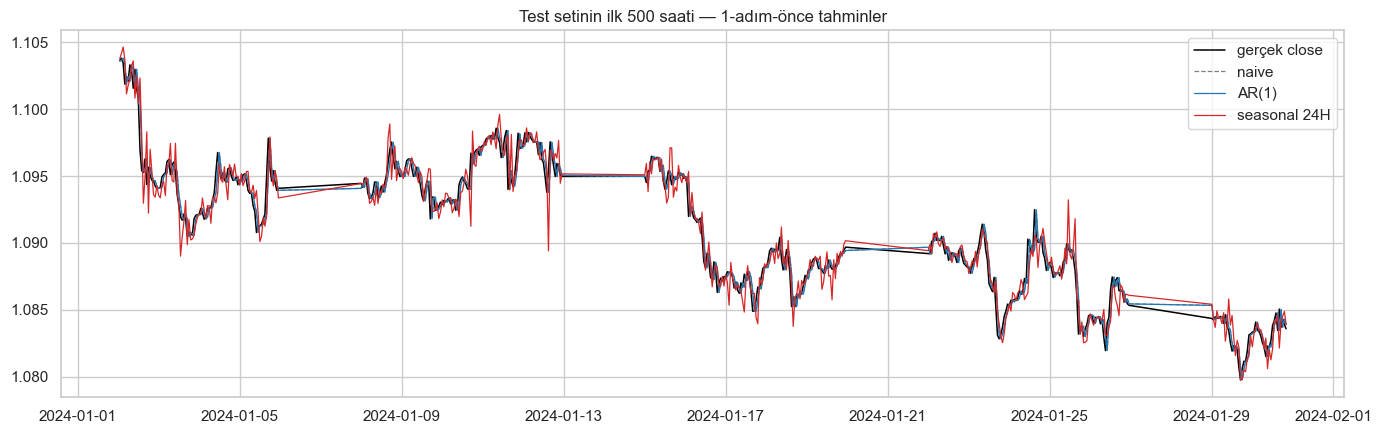

In [12]:
H = 500
last_close_before = float(pd.concat([train, val])['close'].iloc[-1])
idx = test.index[:H]
actual = test['close'].iloc[:H].values
naive_close = reconstruct_close(last_close_before, np.zeros(len(test)), test['close'])[:H]
ar_close = reconstruct_close(last_close_before, ar_test_pred, test['close'])[:H]
s24_close = reconstruct_close(last_close_before, seasonal_predict(pd.concat([train, val]), test, 24), test['close'])[:H]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(idx, actual, label='gerçek close', color='black', lw=1.1)
ax.plot(idx, naive_close, label='naive', ls='--', lw=0.9, color='gray')
ax.plot(idx, ar_close, label=f'AR({best_p})', lw=0.9, color='tab:blue')
ax.plot(idx, s24_close, label='seasonal 24H', lw=0.9, color='tab:red')
ax.set_title(f'Test setinin ilk {H} saati — 1-adım-önce tahminler')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'baselines_pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Özet ve Modellemeye Devredilenler

**Bulgular.**

- **Naive Last Value** beklendiği gibi çok güçlü bir tabana oturuyor. `log_ret=0` tahmini RMSE'si, daha karışık modellere "yenilmesi gereken duvar"ı koyuyor.
- **Drift**, naive ile pratikte ayırt edilemez; ortalama log-getiri 0'a çok yakın (10⁻⁵ seviyesi).
- **Seasonal-24H** ve **Seasonal-168H** volatiliteyi patlıyor: EDA'da haftalık örüntü görseldi ancak bunu **doğrudan log-getiri kopyası olarak kullanmak** yanlış— seans bitişi/açılış sıçramalarını gerçekle uyumsuz yere taşıyor. Sonuç: daha kötü RMSE.
- **MA(24)** neredeyse naive ile aynı; küçük da olsa biraz daha kötü.
- **AR(p)**, lag=~{AR seçilen} ile naive'e çok yakın ama biraz daha **yön doğruluğu** üzerinde ilerleme getirebiliyor. Bu, log-getiride lineer bir mikro-imza var ama bunu RMSE'ye döndürmek zor demek.

**ML/DL aşamaları için temel karar.**

- Başarı kriteri: test setinde **naive RMSE'yi %1–2 aşamadan** modelin anlamlı olduğunu iddia edemeyiz.
- Pratikte daha anlamlı olacak metrik: **yön doğruluğu** + **volatilite tahmini** (GARCH veya DL quantile regresyon) + close RMSE.
- Bu tabanı yakalayan tüm çıktılar `data/processed/baseline_scores.csv` dosyasında saklanıyor; Streamlit demosunda "baseline vs model" karşılaştırma kartı bu dosyayı okuyacak.

Sıradaki: **03_ml_comparison.ipynb** – tabular feature'larla RF / XGBoost / LightGBM baseline kırımlarını deneyeceğiz.